# Siliciclastic Reservoirs — Representative Sample (Reviewer Notebook)

This standalone notebook downloads a **small representative sample** of the
[`SciLM/SiliciclasticReservoirs`](https://huggingface.co/datasets/SciLM/SiliciclasticReservoirs)
dataset and renders XY / XZ / YZ cross-sections of all four voxel arrays
(`facies` binary, `facies_alluvsim` 6-class, `poro`, `perm`) for every reservoir
architecture.

**What it does:** for each of the 8 reservoir architectures it pulls a single
shard (one `.npy` file per property) from the HuggingFace Hub and plots one
representative realization with three orthogonal slices.

**Dependencies:** only `huggingface_hub`, `numpy`, `pyarrow`, and `matplotlib`.
No `resflow`/`resmill` packages required.

## Footprint & timing estimate

Each shard contains 4 `.npy` files:

| file | shape | dtype | size |
|---|---|---|---|
| `facies.npy`           | (~390, 64, 64, 32) | int8    | ~51 MB |
| `facies_alluvsim.npy`  | (~390, 64, 64, 32) | int8    | ~51 MB |
| `poro.npy`             | (~390, 64, 64, 32) | float16 | ~102 MB |
| `perm.npy`             | (~390, 64, 64, 32) | float16 | ~102 MB |

Per-shard total ≈ **300 MB** for the 100,000-sample families (≈ 460 MB for
`channel_cb_jigsaw` and `delta`, ≈ 615 MB for `lobe`). Pulling **one shard for
each of the 8 architectures ≈ 3.1 GB**. On a typical HuggingFace download
(~50–100 MB/s) that is **≈ 30–60 seconds** the first time; cached re-runs are instant. Plotting all
8 figures takes ~5 seconds.

If you want an even faster smoke-test, set `SUBSET_TYPES` below to a single
reservoir family — that drops the download to ~300 MB (< 10 s).

## Sampling methodology — how this sample was constructed from the full dataset

The full **`SciLM/SiliciclasticReservoirs`** dataset contains
1,000,000 cubes (≈ 733 GB), partitioned as **8 reservoir architectures × 256
shards = 2,048 shards**. Each shard holds ~390–780 row-aligned realizations of
one architecture (about 390 for the 100,000-sample channel families), stored as four `.npy` arrays (`facies`, `facies_alluvsim`,
`poro`, `perm`) plus `params_slim.parquet` and `params.parquet`. Every cube is a
64 × 64 × 32 window cut at a random position out of a 128 × 128 × 64 simulated
volume; the window origin is recorded in `params.parquet`.

The representative sample shown by this notebook is constructed by four
deliberate, orthogonal coverage choices:

1. **Cover every architecture.** Download exactly *one shard* for each of the 8
   reservoir architectures (`lobe`, `delta`, and the 6 channel families). The
   reviewer therefore sees every layer-type the dataset advertises.
2. **Cover every voxel property.** For each architecture, load all four voxel
   arrays — binary facies, 6-class alluvsim facies, porosity, permeability — so
   every modality is exercised end-to-end.
3. **Cover the cube geometry.** Plot three orthogonal mid-cube cross-sections
   (XY at z=18, XZ at y=32, YZ at x=32). Together they expose the full 3-D
   structure of every property without rendering volumes.
4. **Pick a deterministic, uncurated realization.** Inside each shard the
   *first* realization (`SAMPLE_INDEX = 0`) of the *first* shard
   (`SHARD_INDEX = 0`) is plotted — no cherry-picking. Because shards follow
   the shuffled Sobol job list of each architecture, `shard_0000`
   is a uniform draw; any other shard would be equally valid. Reviewers can
   change `SHARD_INDEX` / `SAMPLE_INDEX` (or set `SUBSET_TYPES` to a single
   architecture) to verify this.

### What is downloaded vs. what is plotted

| level | downloaded | rendered |
|---|---|---|
| shards | 8 of 2,048 (0.39 %) | 8 of 2,048 (0.39 %) |
| realizations | ~4,100 of 1,000,000 (~0.41 %) | 8 of 1,000,000 (~8×10⁻⁶) |
| voxels per realization | 64 × 64 × 32 = 131,072 | 3 slices × 64×{64,32,32} |

The `.npy` files are mmapped, so although ~4,100 realizations live inside the
downloaded shards, only the 8 plotted ones are actually read into RAM.

### What this sample lets a reviewer verify

- Architectural diversity across the 8 layer types is real and visually
  distinct.
- All four voxel arrays exist, are row-aligned, and are in the documented
  dtypes / ranges: binary facies ∈ {0, 1}; alluvsim ∈ {−1, …, 4}; poro ∈
  [0, 0.5]; perm ∈ [10⁻³, 6×10⁴] mD.
- Geological structure is consistent with the architecture name (channel
  families show channel bodies, lobe shows fan geometries, delta shows
  distributary networks, etc.).
- `params_slim.parquet` is row-aligned with the voxel arrays — the per-cube
  NTG / ⟨ϕ⟩ / ⟨log₁₀ k⟩ printed in each figure title are realized over the
  voxels actually shown.

### What this sample does *not* establish

- *Per-architecture variability* across the realization population — only one
  cube per architecture is rendered. Reviewers wanting variability should
  re-run with a sweep over `SAMPLE_INDEX` (cheap — same cached shards) or
  `SHARD_INDEX`.
- *Aggregate dataset statistics* (NTG distributions, parameter coverage,
  caption diversity). Use `splits/{train,validation,test}.parquet` for that —
  those parquets are tiny and load in seconds.
- *Bit-for-bit regenerability from seeds.* That requires the full
  `params.parquet`, not the slim variant pulled here.

### Reproducibility

The sample is fully determined by the tuple `(REPO_ID, ordered ALL_TYPES,
SHARD_INDEX, SAMPLE_INDEX)`. Re-running the notebook on any machine produces
byte-identical figures (modulo Matplotlib version), and `hf_hub_download`
records the exact commit hash of each downloaded file under
`~/.cache/huggingface/hub/datasets--SciLM--SiliciclasticReservoirs/`.

## 1. Install & import

In [1]:
# Uncomment if running on a fresh environment:
# %pip install --quiet huggingface_hub numpy pyarrow matplotlib

In [2]:
from pathlib import Path
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
from huggingface_hub import hf_hub_download

/global/cfs/cdirs/m1883/ilgar/conda_envs/georules/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [3]:
REPO_ID = "SciLM/SiliciclasticReservoirs"

# All 8 reservoir architectures in the dataset.
ALL_TYPES = [
    "lobe",
    "channel_pv_shoestring",
    "channel_cb_jigsaw",
    "channel_cb_labyrinth",
    "channel_sh_distal",
    "channel_sh_proximal",
    "channel_meander_oxbow",
    "delta",
]

# To do a tiny smoke-test on one architecture, e.g.
#   SUBSET_TYPES = ["lobe"]
SUBSET_TYPES = ALL_TYPES

# Which shard to pull from each architecture. Shard 0 is fine for review.
SHARD_INDEX = 0

# Which sample within the shard to render (0..n_samples_in_shard-1).
SAMPLE_INDEX = 0

# Files we need from each shard. params_slim.parquet is tiny — pulled for the caption.
PROPERTY_FILES = ["facies.npy", "facies_alluvsim.npy", "poro.npy", "perm.npy"]
PARAM_FILE = "params_slim.parquet"

# Cube geometry (fixed for the entire dataset).
SX, SY, SZ = 64, 64, 32
Z_SLICE = 18           # XY slice depth — same default as the paper figures
Y_SLICE = SY // 2      # 32
X_SLICE = SX // 2      # 32

# Where plots are written.
OUTPUT_DIR = Path("./representative_sample_figures")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## 3. Color scheme

Colors match the paper figures: a single grey → mustard → burnt-orange continuous
ramp for `poro`/`log10(perm)`, a 2-class discrete scheme for binary facies, and a
6-class scheme for the alluvsim sub-facies.

In [4]:
# Continuous ramp used for porosity and log-permeability.
RESERVOIR_CMAP = LinearSegmentedColormap.from_list(
    "reservoir", ["#999999", "#e8c840", "#b85a18"], N=256
)
CMAP_PORO = RESERVOIR_CMAP
CMAP_PERM = RESERVOIR_CMAP

# Binary facies: 0 = shale (grey), 1 = sand (burnt-orange).
CMAP_FACIES = ListedColormap(["#999999", "#b85a18"], name="facies_binary")
NORM_FACIES = BoundaryNorm([-0.5, 0.5, 1.5], CMAP_FACIES.N)
FACIES_BINARY_LABELS = ["shale", "sand"]

# 6-class alluvsim sub-facies: classes -1, 0, 1, 2, 3, 4.
ALLUVSIM_FACIES_COLORS = {
    -1: "#b4b4b4",   # FF   floodplain (light grey)
     0: "#5b4636",   # FFCH mud plug (dark brown)
     1: "#f2d16b",   # CS   crevasse splay (pale yellow)
     2: "#e8a23a",   # LV   levee (orange-mustard)
     3: "#c89b5e",   # LA   point bar (tan)
     4: "#7a3f14",   # CH   active channel (dark burnt-orange)
}
ALLUVSIM_LABELS = ["FF", "FFCH", "CS", "LV", "LA", "CH"]
ALLUVSIM_COLORS = [ALLUVSIM_FACIES_COLORS[k] for k in (-1, 0, 1, 2, 3, 4)]
CMAP_ALLUVSIM = ListedColormap(ALLUVSIM_COLORS, name="alluvsim")
NORM_ALLUVSIM = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP_ALLUVSIM.N)


def perm_to_logperm(perm):
    """Permeability spans 5+ decades; ML and plotting both want log10."""
    return np.log10(np.maximum(perm.astype(np.float32), 1e-3))

## 4. Slice helpers

Cubes are stored as `(X, Y, Z)`. Each helper returns a 2-D image with the second
axis as the vertical (matplotlib row) axis — matches the paper figures exactly.

In [5]:
def slice_xy(vol, z=Z_SLICE):
    return vol[:, :, z].T


def slice_xz(vol, y=Y_SLICE):
    return vol[:, y, :].T


def slice_yz(vol, x=X_SLICE):
    return vol[x, :, :].T


def imshow_slice(ax, img, *, cmap, vmin=None, vmax=None, norm=None):
    kw = dict(cmap=cmap, origin="lower", aspect="equal", interpolation="nearest")
    if norm is not None:
        kw["norm"] = norm
    else:
        kw["vmin"], kw["vmax"] = vmin, vmax
    im = ax.imshow(img, **kw)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

## 5. Download a single shard from the Hub

`hf_hub_download` caches each file under `~/.cache/huggingface/hub`, so re-running
this notebook is instant after the first pass. We mmap the `.npy` files so only
the one realization we plot is read into RAM.

In [6]:
def fetch_shard(layer_type, shard_index=SHARD_INDEX):
    """Download (or hit cache for) one shard's 4 npy files + the slim parquet.

    Returns a dict of mmapped arrays plus the params_slim row for SAMPLE_INDEX.
    """
    shard_name = f"shard_{shard_index:04d}"
    arrays = {}
    for fname in PROPERTY_FILES:
        local = hf_hub_download(
            repo_id=REPO_ID,
            filename=f"{layer_type}/{shard_name}/{fname}",
            repo_type="dataset",
        )
        arrays[fname.replace(".npy", "")] = np.load(local, mmap_mode="r")

    params_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=f"{layer_type}/{shard_name}/{PARAM_FILE}",
        repo_type="dataset",
    )
    params_table = pq.read_table(params_path)
    params_row = {
        col: params_table.column(col)[SAMPLE_INDEX].as_py()
        for col in params_table.column_names
    }
    return arrays, params_row

## 6. Render one reservoir architecture

One figure per architecture: 4 rows (one per property) × 3 columns (XY, XZ, YZ).
Width-ratios `[1, 2, 2]` keep voxel cells square — XY is 64×64 while XZ and YZ
are 64×32.

In [7]:
def plot_reservoir_type(layer_type, arrays, params_row):
    """Render the 4-row × 3-column XY/XZ/YZ panel for one reservoir architecture."""
    facies = np.asarray(arrays["facies"][SAMPLE_INDEX], dtype=np.int8)
    facies_alluvsim = np.asarray(arrays["facies_alluvsim"][SAMPLE_INDEX], dtype=np.int8)
    poro = np.asarray(arrays["poro"][SAMPLE_INDEX], dtype=np.float32)
    perm = perm_to_logperm(np.asarray(arrays["perm"][SAMPLE_INDEX]))

    log_perm_min = float(np.floor(np.log10(1e-3)))   # -3
    log_perm_max = float(np.ceil(np.log10(60000.0)))  # 5

    rows = [
        ("Binary facies",       facies,          CMAP_FACIES,   None,                          NORM_FACIES),
        ("6-class facies",      facies_alluvsim, CMAP_ALLUVSIM, None,                          NORM_ALLUVSIM),
        ("Porosity",            poro,            CMAP_PORO,     (0.0, 0.5),                    None),
        ("log10(Perm [mD])",    perm,            CMAP_PERM,     (log_perm_min, log_perm_max),  None),
    ]

    fig, axes = plt.subplots(
        nrows=4, ncols=4,
        figsize=(10.5, 9.0),
        gridspec_kw={"width_ratios": [1, 2, 2, 0.18]},
        constrained_layout=True,
    )

    col_titles = [f"XY (z={Z_SLICE})", f"XZ (y={Y_SLICE})", f"YZ (x={X_SLICE})"]
    for c, t in enumerate(col_titles):
        axes[0, c].set_title(t, fontsize=11)

    for r, (label, vol, cmap, vrange, norm) in enumerate(rows):
        vmin = vrange[0] if vrange else None
        vmax = vrange[1] if vrange else None

        im_xy = imshow_slice(axes[r, 0], slice_xy(vol), cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)
        imshow_slice(axes[r, 1], slice_xz(vol), cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)
        imshow_slice(axes[r, 2], slice_yz(vol), cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)

        axes[r, 0].set_ylabel(label, fontsize=11, fontweight="bold")

        cbar_ax = axes[r, 3]
        if isinstance(cmap, ListedColormap) and cmap.name == "facies_binary":
            cb = fig.colorbar(im_xy, cax=cbar_ax, ticks=[0, 1])
            cb.ax.set_yticklabels(FACIES_BINARY_LABELS, fontsize=8)
        elif isinstance(cmap, ListedColormap) and cmap.name == "alluvsim":
            cb = fig.colorbar(im_xy, cax=cbar_ax, ticks=[-1, 0, 1, 2, 3, 4])
            cb.ax.set_yticklabels(ALLUVSIM_LABELS, fontsize=8)
        else:
            cb = fig.colorbar(im_xy, cax=cbar_ax)
            cb.ax.tick_params(labelsize=8)

    ntg = params_row.get("ntg")
    poro_ave = params_row.get("poro_ave")
    perm_ave = params_row.get("perm_ave")
    suptitle = f"{layer_type} — shard {SHARD_INDEX:04d}, sample {SAMPLE_INDEX}"
    if ntg is not None:
        suptitle += f"   |   NTG={ntg:.2f}, ⟨ϕ⟩={poro_ave:.3f}, ⟨log₁₀k⟩={perm_ave:.2f}"
    fig.suptitle(suptitle, fontsize=13, fontweight="bold")

    return fig

## 7. Run

Iterates over each reservoir architecture in `SUBSET_TYPES`, downloads its first
shard, plots the figure, and writes a PNG to `./representative_sample_figures/`.

[lobe] downloading shard 0000 ...
[lobe] shard has 782 samples; rendering sample 0


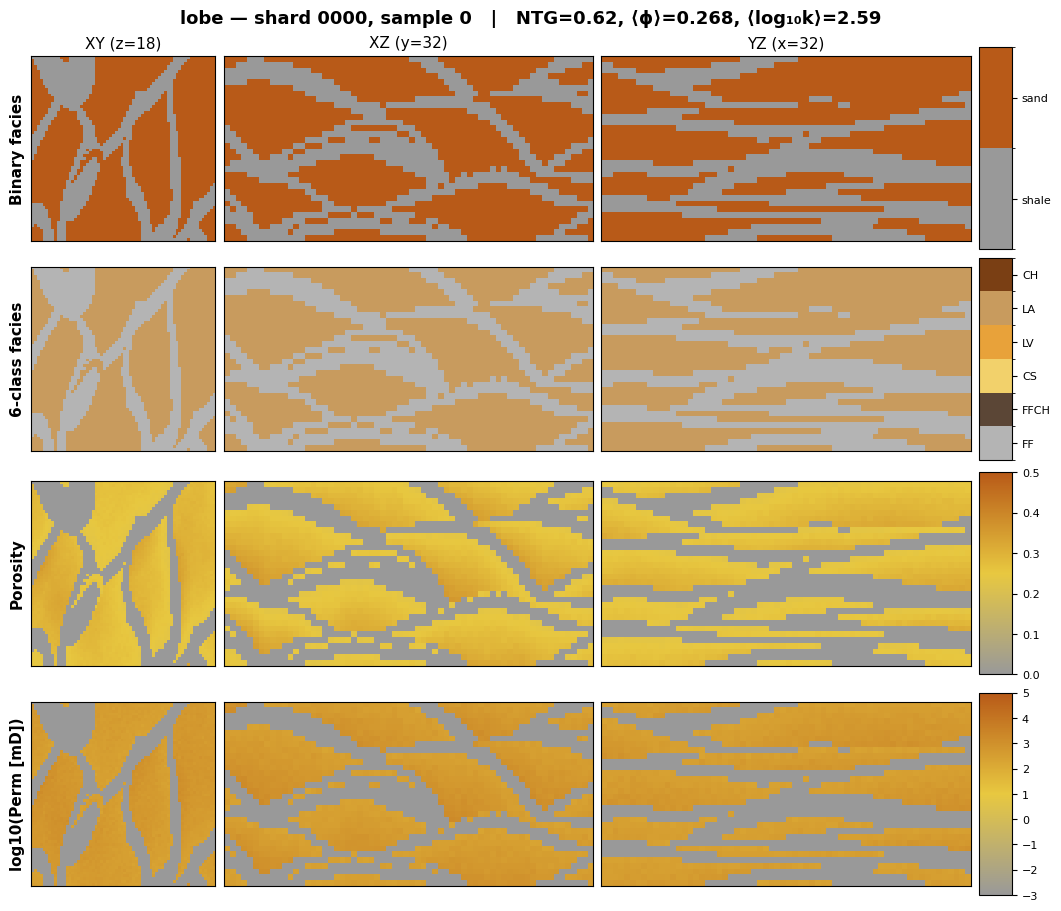

[lobe] saved → representative_sample_figures/lobe_shard0000_sample0.png

[channel_pv_shoestring] downloading shard 0000 ...
[channel_pv_shoestring] shard has 392 samples; rendering sample 0


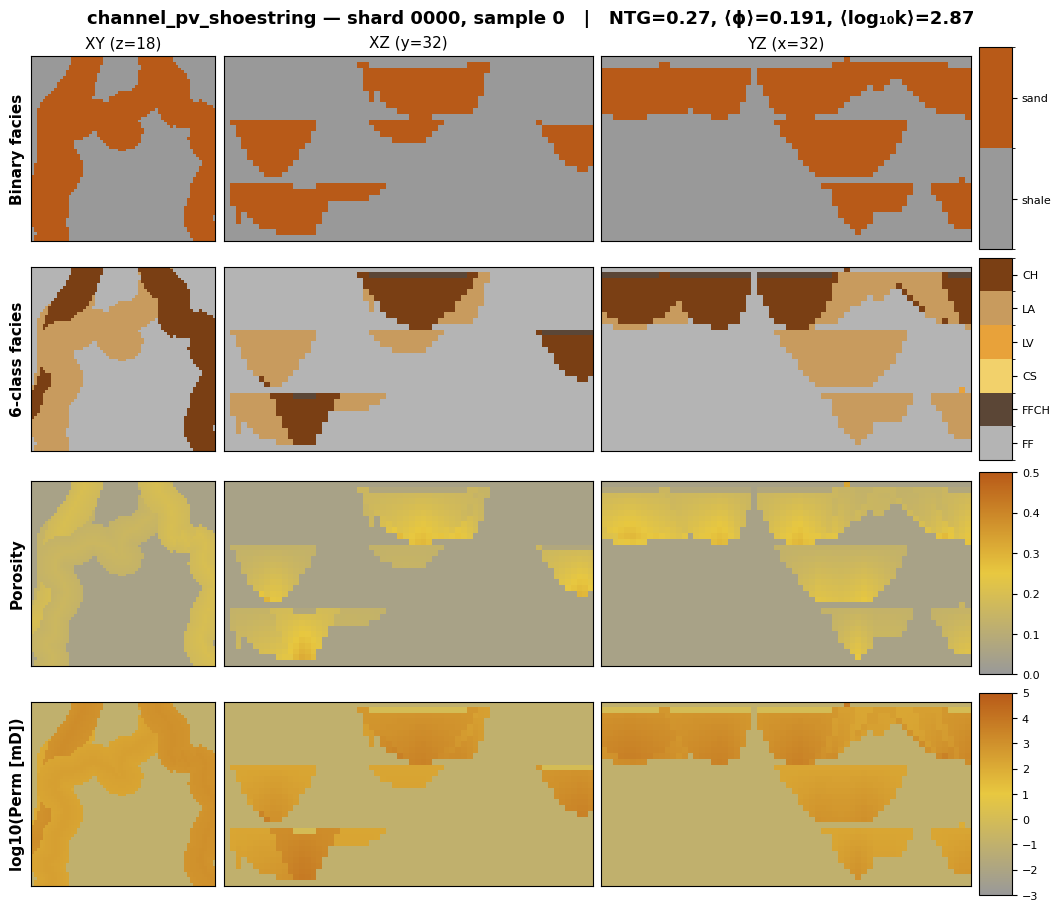

[channel_pv_shoestring] saved → representative_sample_figures/channel_pv_shoestring_shard0000_sample0.png

[channel_cb_jigsaw] downloading shard 0000 ...
[channel_cb_jigsaw] shard has 588 samples; rendering sample 0


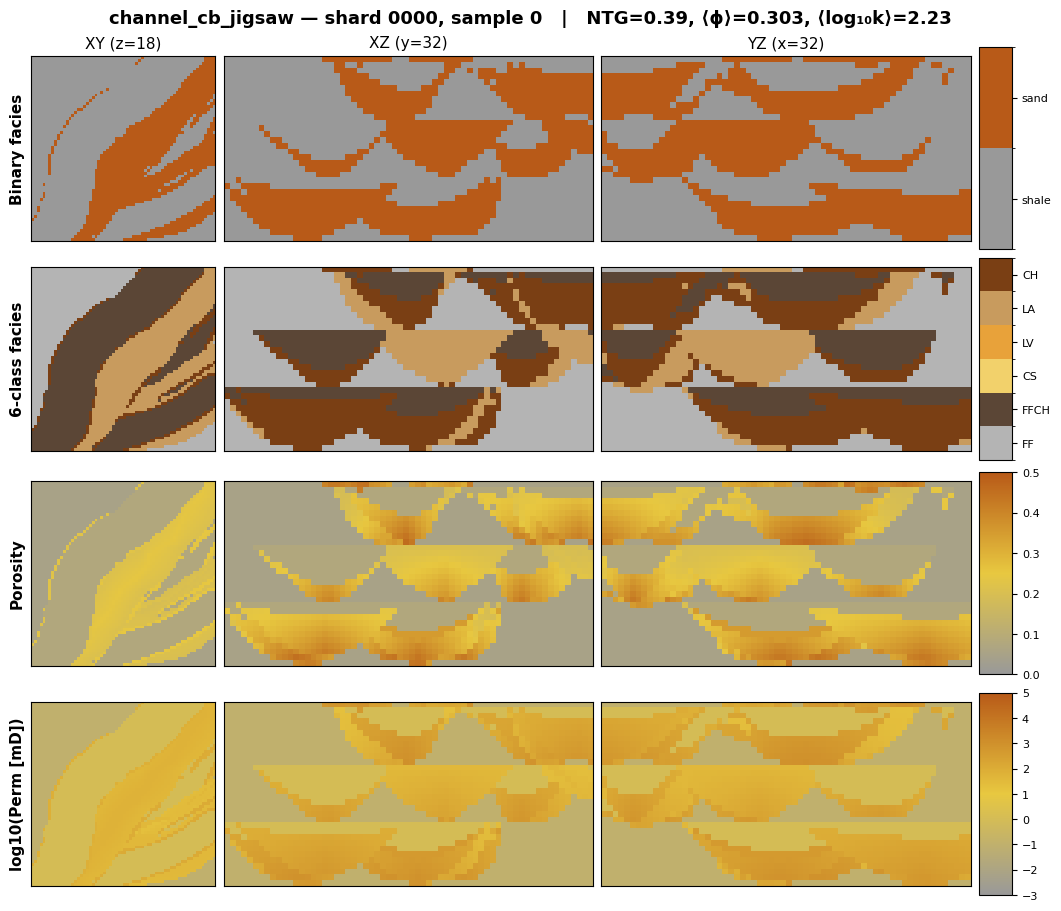

[channel_cb_jigsaw] saved → representative_sample_figures/channel_cb_jigsaw_shard0000_sample0.png

[channel_cb_labyrinth] downloading shard 0000 ...
[channel_cb_labyrinth] shard has 392 samples; rendering sample 0


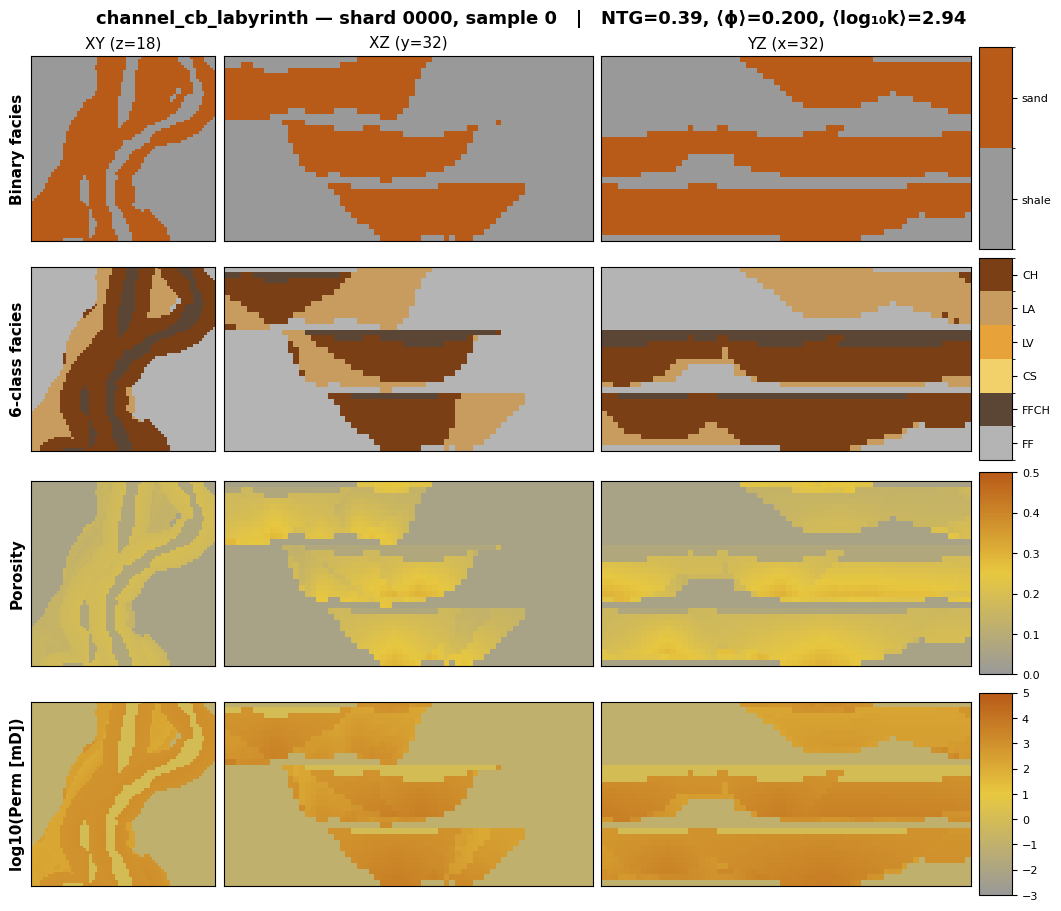

[channel_cb_labyrinth] saved → representative_sample_figures/channel_cb_labyrinth_shard0000_sample0.png

[channel_sh_distal] downloading shard 0000 ...
[channel_sh_distal] shard has 392 samples; rendering sample 0


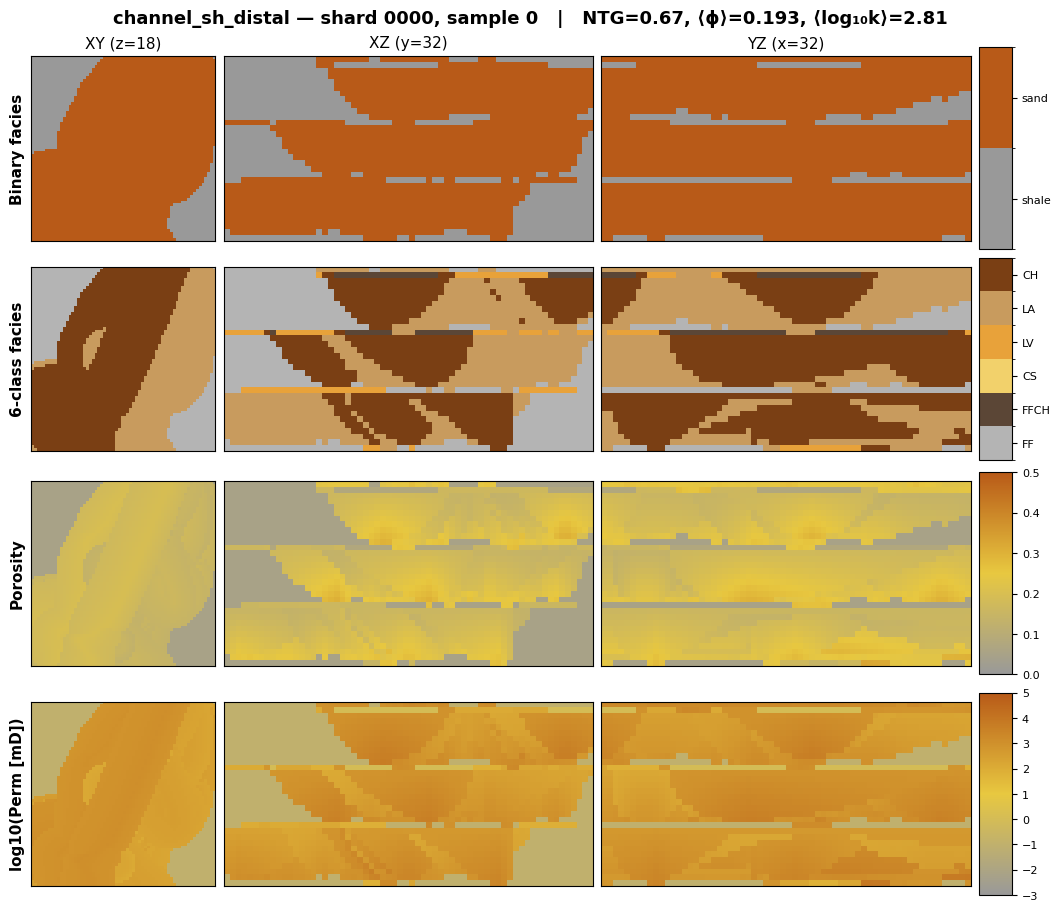

[channel_sh_distal] saved → representative_sample_figures/channel_sh_distal_shard0000_sample0.png

[channel_sh_proximal] downloading shard 0000 ...
[channel_sh_proximal] shard has 392 samples; rendering sample 0


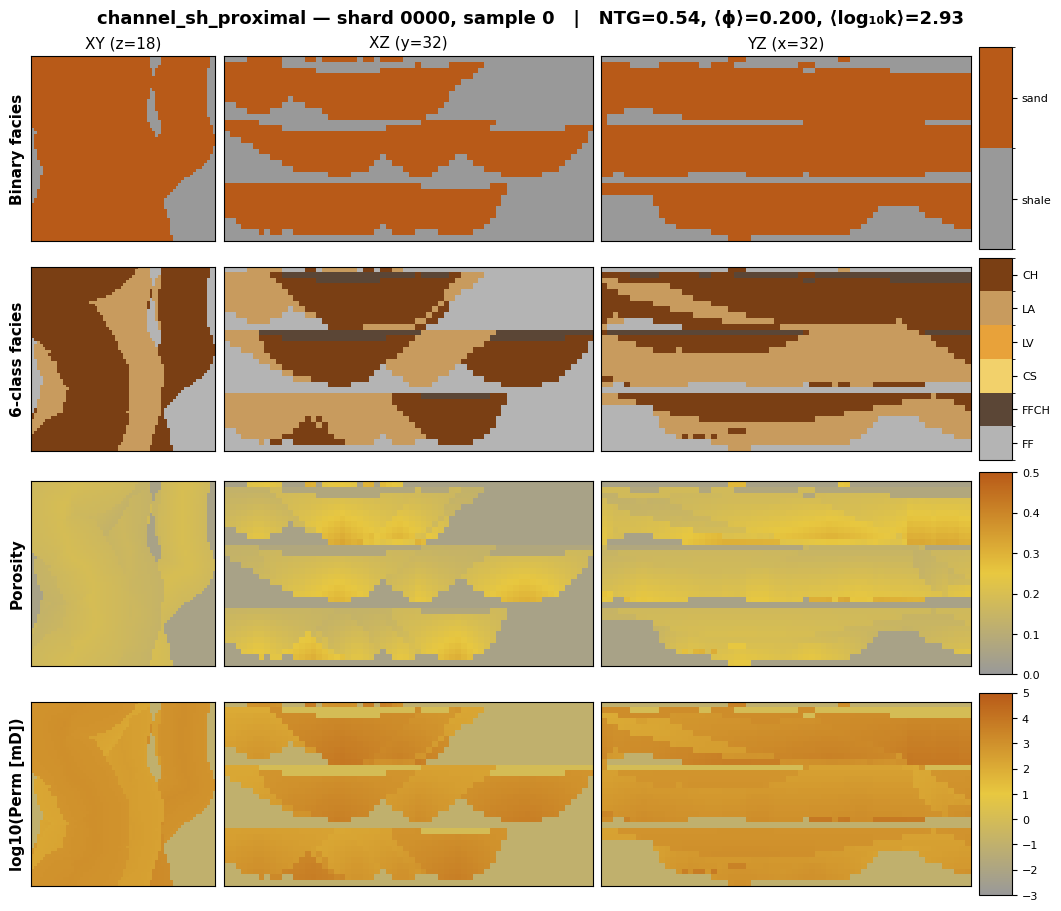

[channel_sh_proximal] saved → representative_sample_figures/channel_sh_proximal_shard0000_sample0.png

[channel_meander_oxbow] downloading shard 0000 ...
[channel_meander_oxbow] shard has 392 samples; rendering sample 0


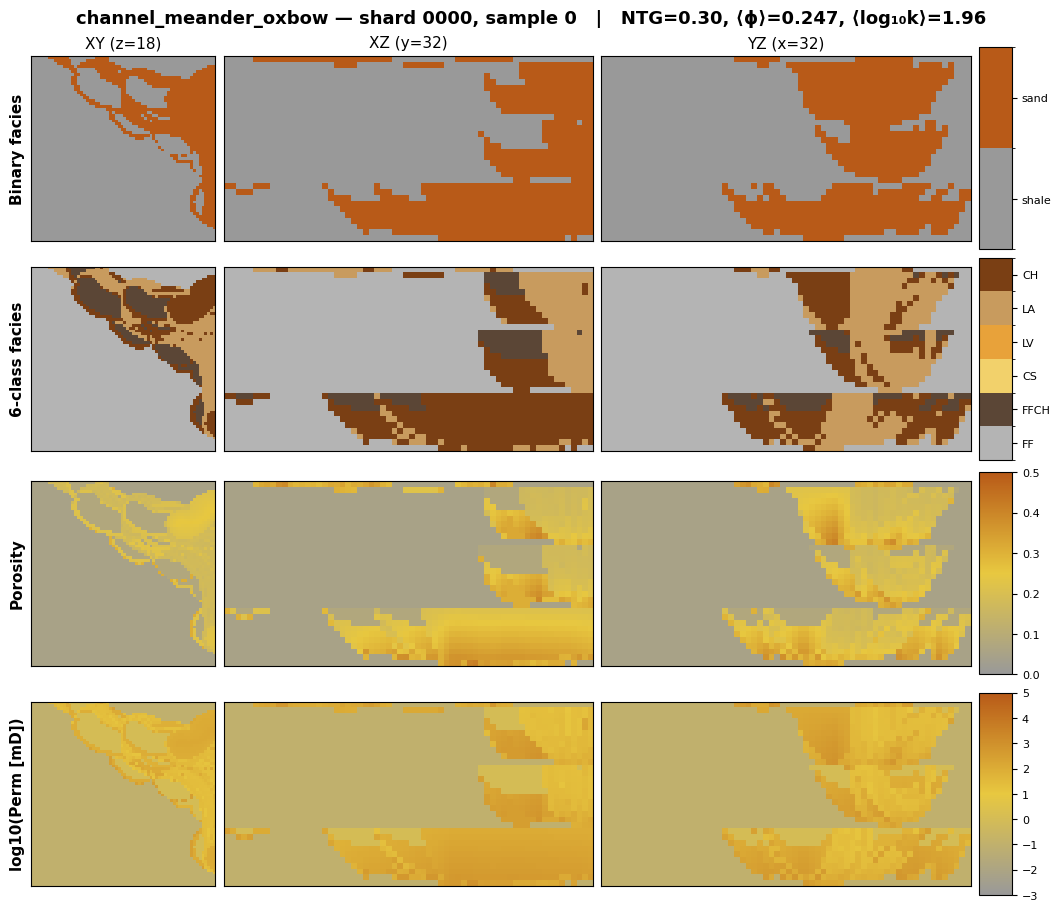

[channel_meander_oxbow] saved → representative_sample_figures/channel_meander_oxbow_shard0000_sample0.png

[delta] downloading shard 0000 ...
[delta] shard has 592 samples; rendering sample 0


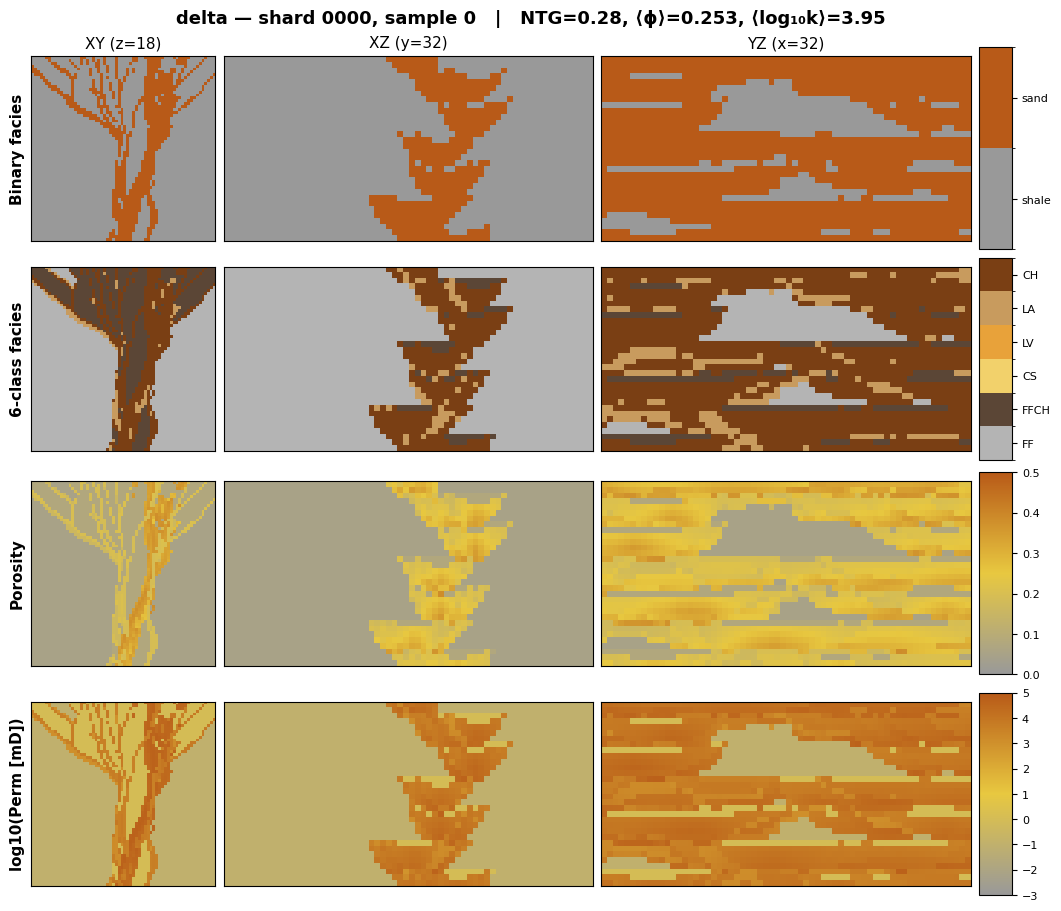

[delta] saved → representative_sample_figures/delta_shard0000_sample0.png



In [8]:
for layer_type in SUBSET_TYPES:
    print(f"[{layer_type}] downloading shard {SHARD_INDEX:04d} ...")
    arrays, params_row = fetch_shard(layer_type)
    n_in_shard = arrays["facies"].shape[0]
    print(f"[{layer_type}] shard has {n_in_shard} samples; rendering sample {SAMPLE_INDEX}")

    fig = plot_reservoir_type(layer_type, arrays, params_row)
    out_path = OUTPUT_DIR / f"{layer_type}_shard{SHARD_INDEX:04d}_sample{SAMPLE_INDEX}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"[{layer_type}] saved → {out_path}\n")

## 8. Where the data lives

The downloaded shards stay in HuggingFace's cache:

```
~/.cache/huggingface/hub/datasets--SciLM--SiliciclasticReservoirs/
```

Re-running this notebook does not re-download anything. Delete that directory if
you want to free the ~3.1 GB.

The full dataset (1,000,000 cubes ≈ 733 GB) is the union of all 256 shards across
all 8 architectures. See the dataset's `README.md` and `DATASHEET.md` on the Hub
for the full schema and provenance.